In [9]:
import os, time
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy import signal

from redpitaya_control.redpitaya_dev import redpitaya_dev
from redpitaya_control.event_logger import EventLogger, unpack, load_run, fit_clock, counter_to_unix
from redpitaya_control import compute_coeff


import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.special import factorial


import scipy.signal as signal




MAX_Q15 = 32767 / 32768
C1 = 99.90741625
C2 = 1225.60912165
C3 = 1024.0
C4 = 14.4

MAX_Q15 = 32767 / 32768



import numpy as np

# Your known calibration points
cal_adu = np.array([450, 1243, 12216])
cal_kev = np.array([6.395, 14.4129, 122.06])

# Calculate the quadratic fit (2nd-degree polynomial)
a, b, c = np.polyfit(cal_adu, cal_kev, deg=2)

print(f"a = {a:e}")
print(f"b = {b:e}")
print(f"c = {c:e}")


def adu_to_kev(adu):

    a = -2.555374e-08
    b = 1.015411e-02
    c = 1.830826e+00
    
    return a * (adu ** 2) + b * adu + c


def kev_to_adu(kev):
    a = -2.555374e-08
    b = 1.015411e-02
    c = 1.830826e+00
    
    # Calculate ADU using the positive root of the quadratic formula
    adu = (-b + np.sqrt(b**2 - 4 * a * (c - kev))) / (2 * a)
    
    return adu





a = -2.555374e-08
b = 1.015411e-02
c = 1.830826e+00


In [10]:
import numpy as np


def process_runfile(runfile, rng=None):
    if rng is None:
        rng = np.random.default_rng()

    # 1. Load and unpack data
    raw = load_run(f"{runfile}/events_*.bin")
    
    ts_us, energy, chb = unpack(raw)
    chb = np.round(chb).astype(int)
    print(chb)

    # Filter positive timestamps and keep energy aligned
    valid_mask = ts_us > 0
    ts_us = ts_us[valid_mask]
    energy = energy[valid_mask]
    chb = chb[valid_mask]

    if len(ts_us) > 1:
        print(
            f"[{runfile}] {len(ts_us)} events, span {(ts_us[-1]-ts_us[0])/1e6:.1f} s"
        )
    else:
        print(f"[{runfile}] No events found.")
        return None

    # Clock drift correction
    a, b, ppm = fit_clock(f"{runfile}/tiepoints.csv")
    print(f"[{runfile}] Crystal drift: {ppm:+.1f} ppm")
    t_unix = counter_to_unix(ts_us, a, b)

    # 2. Synthetic directional block generation
    # target_len = len(energy)
    # max_blocks = (target_len // 950) + 10
    # block_lengths = rng.integers(950, 1060, size=max_blocks)

    # signs = np.where(np.arange(max_blocks) % 2 == 0, 1, -1)
    # chb = np.repeat(signs, block_lengths)[:target_len] ##TODO, Fix

    # 3. Chunk splitting
    split_indices = np.where(np.diff(chb) != 0)[0] + 1

    raw_energy_chunks = np.split(energy, split_indices)
    raw_ts_chunks = np.split(ts_us, split_indices)
    raw_chb_chunks = np.split(chb, split_indices)

    # 3b. Trim the first 50 ms (50,000 µs) off each direction chunk
    TRIM_US = 50_000
    
    energy_chunks = []
    ts_chunks = []
    chb_chunks = []

    for e, t, c in zip(raw_energy_chunks, raw_ts_chunks, raw_chb_chunks):
        if len(t) == 0:
            continue
        
        # Keep events occurring >= 50ms from chunk start
        mask = t >= (t[0] + TRIM_US)
        
        if np.any(mask):
            energy_chunks.append(e[mask])
            ts_chunks.append(t[mask])
            chb_chunks.append(c[mask])

    chunk_directions = [c[0] for c in chb_chunks]

    # 4. Group into forward and backward lists
    forward_energies = [
        e for e, d in zip(energy_chunks, chunk_directions) if d == 1
    ]
    backward_energies = [
        e for e, d in zip(energy_chunks, chunk_directions) if d == 0
    ]

    forward_times = [
        t for t, d in zip(ts_chunks, chunk_directions) if d == 1
    ]
    backward_times = [
        t for t, d in zip(ts_chunks, chunk_directions) if d == 0
    ]

    return {
        "runfile": runfile,
        "ts_us": ts_us,
        "energy": energy,
        "t_unix": t_unix,
        "chb": chb,
        "energy_chunks": energy_chunks,
        "ts_chunks": ts_chunks,
        "chunk_directions": np.array(chunk_directions),
        "forward_energies": forward_energies,
        "backward_energies": backward_energies,
        "forward_times": forward_times,
        "backward_times": backward_times,
    }


In [11]:

# --- Process Multiple Files ---
runfiles = [
    '100_runfile',
    '90_runfile',
    '80_runfile',
    '70_runfile',
    '60_runfile',
    '50_runfile',
    '40_runfile',
    '30_runfile',
    '20_runfile',
    '10_runfile',
    '04_runfile',
    '02_runfile'

]

rng = np.random.default_rng()
processed_runs = {}

for rf in runfiles:
    result = process_runfile(rf, rng=rng)
    if result is not None:
        processed_runs[rf] = result

# --- Example Accessing Results ---
# Access File 1's forward times:
# fwd_times_file1 = processed_runs['time_analysis_new_source_ten_minute']['forward_times']


[1 1 1 ... 1 1 1]
[100_runfile] 284389 events, span 300.2 s
[100_runfile] Crystal drift: +0.5 ppm
[0 0 0 ... 0 0 0]
[90_runfile] 284417 events, span 300.1 s
[90_runfile] Crystal drift: +14.6 ppm
[1 1 1 ... 0 0 0]
[80_runfile] 285541 events, span 300.8 s
[80_runfile] Crystal drift: -23.3 ppm
[1 1 1 ... 0 1 0]
[70_runfile] 283896 events, span 300.4 s
[70_runfile] Crystal drift: +5.2 ppm
[0 0 0 ... 0 0 0]
[60_runfile] 283093 events, span 300.5 s
[60_runfile] Crystal drift: -3.1 ppm
[0 0 0 ... 0 0 0]
[50_runfile] 282298 events, span 300.7 s
[50_runfile] Crystal drift: +8.9 ppm
[1 1 1 ... 1 1 1]
[40_runfile] 280199 events, span 300.3 s
[40_runfile] Crystal drift: -5.1 ppm
[1 1 1 ... 0 0 0]
[30_runfile] 277201 events, span 300.4 s
[30_runfile] Crystal drift: +6.2 ppm
[0 0 0 ... 0 0 0]
[20_runfile] 271929 events, span 300.7 s
[20_runfile] Crystal drift: -35.1 ppm
[1 1 1 ... 1 1 1]
[10_runfile] 261856 events, span 300.0 s
[10_runfile] Crystal drift: +12.9 ppm
[1 1 1 ... 1 1 1]
[04_runfile] 257

In [12]:
# np.any((processed_runs[runfiles[0]]['chb']==0))

In [13]:
# runfile2 = '00_velocity'
# print("_".join(runfile2.split("_")[:1]))




0.9371874622712307
0.9353605241434293
0.9139326746172801
0.9213707652696401
0.9290578551534362
0.9025325829545489
0.9258646018414117
0.9564112399008596
0.8428871229020792
0.8508862547051773
0.8969679165236162
0.8797189278523713


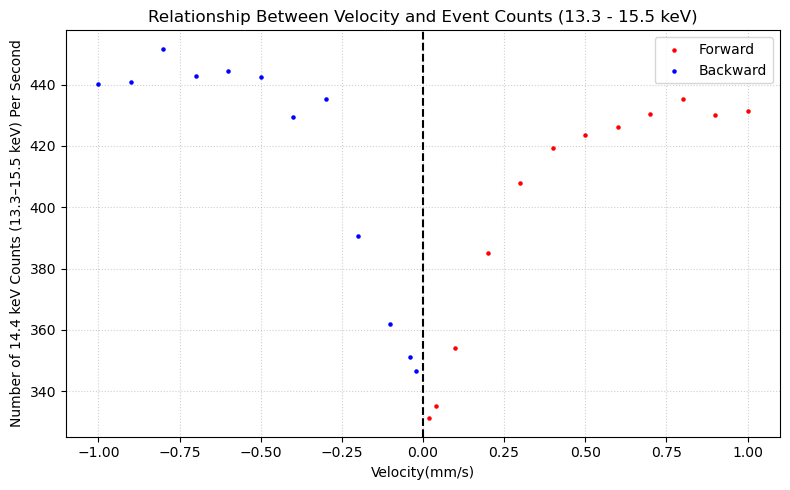

In [14]:
import matplotlib.pyplot as plt
import numpy as np

e_start = 13.3
e_end = 15.5

fwd_vels, fwd_counts = [], []
bwd_vels, bwd_counts = [], []

for runfile in runfiles:
    vel_str = "_".join(runfile.split("_")[:1]).replace("_", ".")
    vel = float(vel_str) / 100

    fwd_chunks = processed_runs[runfile]["forward_energies"]
    bwd_chunks = processed_runs[runfile]["backward_energies"]

    fwd_times = processed_runs[runfile]["forward_times"]
    bwd_times = processed_runs[runfile]["backward_times"]

    # Calculate active duration in seconds
    fwd_dur_s = (
        sum((t[-1] - t[0]) for t in fwd_times if len(t) > 1) / 1e6
        
    )
    bwd_dur_s = (
        sum((t[-1] - t[0]) for t in bwd_times if len(t) > 1) / 1e6
        
    )
    print((fwd_dur_s-bwd_dur_s)/fwd_dur_s)

    fwd_energy_all = np.concatenate(fwd_chunks)
    fwd_kev = adu_to_kev(fwd_energy_all)
    fwd_count = np.sum((fwd_kev >= e_start) & (fwd_kev <= e_end))
    
    fwd_rate = fwd_count / fwd_dur_s 

    # Backward count & rate
    if len(bwd_chunks) > 0:
        bwd_energy_all = np.concatenate(bwd_chunks)
        bwd_kev = adu_to_kev(bwd_energy_all)
        bwd_count = np.sum((bwd_kev >= e_start) & (bwd_kev <= e_end))
    else:
        bwd_count = 0

    bwd_rate = bwd_count / bwd_dur_s 

    # Filter out zeros before plotting
    if fwd_rate > 0:
        fwd_vels.append(vel)
        fwd_counts.append(fwd_rate)

    if bwd_rate > 0:
        bwd_vels.append(-vel)
        bwd_counts.append(bwd_rate)


# --- Plotting ---
plt.figure(figsize=(8, 5))

plt.scatter(
    fwd_vels,
    fwd_counts,
    color="red",
    label="Forward",
    marker="o",
    s=5,
    zorder=3,
)
plt.scatter(
    bwd_vels,
    bwd_counts,
    color="blue",
    label="Backward",
    marker="o",
    s=5,
    zorder=3,
)

plt.title(
    f"Relationship Between Velocity and Event Counts ({e_start} - {e_end} keV)"
)
plt.xlabel("Velocity(mm/s)")
plt.ylabel(f"Number of 14.4 keV Counts ({e_start}–{e_end} keV) Per Second")
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend()
plt.axvline(0, linestyle="--", color = 'black')
plt.tight_layout()
# plt.ylim(0, 80000)
# plt.xlim(-0.2,0.2)
plt.show()


In [15]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
from scipy.special import factorial


def graph_poissonian(
    datasets,
    e_start=14.2,
    e_end=14.6,
    bin=100000,
    direction_mode="all",
    overlay=False,
    save=False,
):
    """Plots Poisson distributions for N datasets with flexible overlaying options.

    Parameters:
    -----------
    datasets : list of tuples
        Format: [(ts_us_1, energy_1, "File 1"), (ts_us_2, energy_2, "File 2", dirs_2), ...]
        Each tuple must contain (ts_us, energy, label), and optionally (directions).
    e_start, e_end : float
        Energy range in keV.
    bin : float
        Time interval bin size in microseconds (us).
    direction_mode : str
        'all'      : Use all timestamps in each dataset (default).
        'split'    : Split each dataset into Forward (dir == 1) and Backward (dir == -1).
        'forward'  : Filter and process only Forward (dir == 1) events.
        'backward' : Filter and process only Backward (dir == -1) events.
    overlay : bool
        If True, overlays all fits/data onto a single plot.
        If False, creates side-by-side subplots.
    save : bool
        If True, saves the figure.
    """
    # --- 1. Process & Filter Datasets ---
    processed_series = []

    for item in datasets:
        ts_us = item[0]
        energy = item[1]
        label = item[2]
        dirs = item[3] if len(item) > 3 else None

        if direction_mode == "split" and dirs is not None:
            fwd_mask = dirs == 1
            bwd_mask = dirs == -1
            if np.any(fwd_mask):
                processed_series.append(
                    (ts_us[fwd_mask], energy[fwd_mask], f"{label} (Forward)")
                )
            if np.any(bwd_mask):
                processed_series.append(
                    (ts_us[bwd_mask], energy[bwd_mask], f"{label} (Backward)")
                )
        elif direction_mode == "forward" and dirs is not None:
            mask = dirs == 1
            processed_series.append(
                (ts_us[mask], energy[mask], f"{label} (Forward)")
            )
        elif direction_mode == "backward" and dirs is not None:
            mask = dirs == -1
            processed_series.append(
                (ts_us[mask], energy[mask], f"{label} (Backward)")
            )
        else:
            processed_series.append((ts_us, energy, label))

    n_series = len(processed_series)
    if n_series == 0:
        print("No datasets available to process.")
        return

    
    if overlay or n_series == 1:
        fig, ax = plt.subplots(figsize=(9, 5))
        axes = [ax] * n_series
    else:
        fig, axes = plt.subplots(
            1, n_series, figsize=(6 * n_series, 4.5), sharey=True
        )

    average_kev = np.average([e_start, e_end])
    colors = plt.cm.tab10(np.linspace(0, 1, max(10, n_series)))
    linestyles = ["--", ":", "-."]
    markers = ["o", "s", "^", "v", "D", "x"]

    # --- 3. Compute and Plot Poisson Fits ---
    for idx, (ts_us, energy, label) in enumerate(processed_series):
        ax = axes[idx]
        color = colors[idx % len(colors)]
        ls = linestyles[idx % len(linestyles)]
        marker = markers[idx % len(markers)]

        energy_kev = adu_to_kev(energy)
        mask = (energy_kev >= e_start) & (energy_kev <= e_end)

        filtered_energies = energy_kev[mask]
        filtered_times_us = ts_us[mask]
        
        

        if len(ts_us) > 0 and len(ts_us[ts_us > 0]) > 0:
            start_time = ts_us[ts_us > 0][0]
            end_time = ts_us[-1]
            # time_bins = np.arange(start_time, end_time + bin, bin)
            # Compute exact number of complete bins
            n_full_bins = int((end_time - start_time) // bin)

            # Generate bin edges strictly covering full intervals
            time_bins = start_time + np.arange(n_full_bins + 1) * bin

            # Calculate frequencies (all bins are guaranteed to be equal width = `bin`)
            frequencies, _ = np.histogram(filtered_times_us, bins=time_bins)

            frequencies, _ = np.histogram(filtered_times_us, bins=time_bins)

            print(f"[{label}] Events in range ({e_start}-{e_end} keV): {len(filtered_energies)}")
            print(f"[{label}] Intervals ({bin/1e3:.1f} ms): {len(frequencies)}")
            print(f"[{label}] Max events/interval: {np.max(frequencies) if len(frequencies) > 0 else 0}")
        else:
            print(f"[{label}] No events to process.")
            continue

        if len(frequencies) == 0 or np.max(frequencies) == 0:
            continue

        max_count = int(np.max(frequencies))
        integer_bins = np.arange(-0.5, max_count + 1.5, 1.0)

        counts, bin_edges = np.histogram(frequencies, bins=integer_bins)
        bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
        total_intervals = len(frequencies)

        # Poisson PMF parameterized for current interval count
        def poisson_pmf(k, lmbda):
            return total_intervals * ((lmbda**k * np.exp(-lmbda)) / factorial(k))

        # Perform Curve Fit
        try:
            popt, pcov = curve_fit(
                poisson_pmf, bin_centers, counts, p0=[np.mean(frequencies)]
            )
            fit_lambda = popt[0]
        except Exception as e:
            print(f"[{label}] Fit failed: {e}")
            continue

        fit_x = np.linspace(0, max_count, 100)

        # Goodness of Fit Statistics
        observed = counts
        expected = poisson_pmf(bin_centers, *popt)
        valid_bins = expected > 0.5

        obs = observed[valid_bins]
        exp = expected[valid_bins]
        sigma = np.sqrt(exp)

        chi_squared = np.sum(((obs - exp) / sigma) ** 2) if len(obs) > 0 else np.nan
        dof = len(obs) - len(popt)
        reduced_chi_squared = chi_squared / dof if dof > 0 else np.nan

        sample_mean = np.mean(frequencies)
        sample_var = np.var(frequencies)
        dispersion = sample_var / sample_mean if sample_mean > 0 else 0

        print(f"[{label}] Variance/Mean Ratio: {dispersion:.3f}")
        print(f"[{label}] Reduced χ²: {reduced_chi_squared:.3f}")
        print(f"[{label}] Fitted Lambda (λ): {fit_lambda:.3f}\n")

        # Plot Fit Line
        ax.plot(
            fit_x,
            poisson_pmf(fit_x, *popt),
            color=color,
            linestyle=ls,
            linewidth=2,
            label=f"{label} Fit (χ²/dof = {reduced_chi_squared:.2f})",
        )

        # Plot Scatter Data Points
        ax.plot(
            bin_centers,
            counts,
            marker=marker,
            linestyle="",
            color=color,
            alpha=0.7,
            label=f"{label} Data",
        )

        ax.set_xlabel(f"Events in a {bin/(1e3):.1f}-ms Interval (k)")
        ax.set_ylabel("Frequency of Occurrence")

        if not overlay:
            ax.set_title(f"{label}: Poisson Fit ({average_kev:.1f} keV)")
            ax.legend()
            ax.grid(True, alpha=0.5)

    if overlay:
        axes[0].set_title(
            f"Poisson Event Rate Distributions ({average_kev:.1f} keV)"
        )
        axes[0].legend()
        axes[0].grid(True, alpha=0.5)

    plt.tight_layout()

    # --- 4. Save Logic ---
    if save:
        base_path = Path(f"poisson_fit_multiaspect_{average_kev:.1f}keV.png")
        stem, suffix, parent = base_path.stem, base_path.suffix, base_path.parent
        save_path = base_path
        counter = 1

        while save_path.exists():
            save_path = parent / f"{stem}_{counter}{suffix}"
            counter += 1

        plt.savefig(save_path, transparent=True, bbox_inches="tight")
        print(f"Saved figure to: {save_path}")

    plt.show()


In [16]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
from scipy.special import factorial


def graph_poissonian(
    datasets,
    e_start=14.2,
    e_end=14.6,
    bin=100000,
    direction_mode="all",
    overlay=False,
    save=False,
):
    """Fits and plots Poisson distributions for N datasets, binning active time

    chunks independently to prevent artificial zero-count spikes during toggled
    states.
    """
    # 1. Expand datasets according to direction_mode
    series = []
    for item in datasets:
        ts_us = item[0]
        energy = item[1]
        label = item[2]
        chb = item[3] if len(item) > 3 else None

        if direction_mode == "split" and chb is not None:
            fwd_mask = chb == 1
            bwd_mask = chb == -1
            if np.any(fwd_mask):
                series.append(
                    (
                        ts_us[fwd_mask],
                        energy[fwd_mask],
                        chb[fwd_mask],
                        f"{label} (Forward)",
                    )
                )
            if np.any(bwd_mask):
                series.append(
                    (
                        ts_us[bwd_mask],
                        energy[bwd_mask],
                        chb[bwd_mask],
                        f"{label} (Backward)",
                    )
                )
        elif direction_mode == "forward" and chb is not None:
            mask = chb == 1
            series.append(
                (ts_us[mask], energy[mask], chb[mask], f"{label} (Forward)")
            )
        elif direction_mode == "backward" and chb is not None:
            mask = chb == -1
            series.append(
                (ts_us[mask], energy[mask], chb[mask], f"{label} (Backward)")
            )
        else:
            series.append((ts_us, energy, None, label))

    if len(series) == 0:
        print("No valid datasets available to process.")
        return

    # 2. Setup Figure Layout
    if overlay or len(series) == 1:
        fig, ax = plt.subplots(figsize=(8.5, 5))
        axes = [ax] * len(series)
    else:
        fig, axes = plt.subplots(
            1, len(series), figsize=(6 * len(series), 4.5), sharey=True
        )

    average_kev = np.average([e_start, e_end])
    colors = plt.cm.tab10(np.linspace(0, 1, max(10, len(series))))
    markers = ["o", "s", "^", "v", "D", "x"]
    linestyles = ["--", ":", "-."]

    # 3. Process each dataset series
    for idx, (ts_us_data, energy_data, chb_sub, file_label) in enumerate(
        series
    ):
        ax = axes[idx]
        color = colors[idx % len(colors)]
        marker = markers[idx % len(markers)]
        linestyle = linestyles[idx % len(linestyles)]

        energy_kev = adu_to_kev(energy_data)

        # Binning chunk-by-chunk if chb transitions exist
        frequencies_list = []

        if chb_sub is not None:
            # Find continuous chunk boundaries within this direction subset
            split_indices = np.where(np.diff(ts_us_data) > bin * 2)[0] + 1
            ts_chunks = np.split(ts_us_data, split_indices)
            e_chunks = np.split(energy_kev, split_indices)

            for chunk_ts, chunk_e in zip(ts_chunks, e_chunks):
                if len(chunk_ts) < 2:
                    continue
                mask = (chunk_e >= e_start) & (chunk_e <= e_end)
                filtered_ts = chunk_ts[mask]

                c_start, c_end = chunk_ts[0], chunk_ts[-1]
                n_full_bins = int((c_end - c_start) // bin)

                if n_full_bins > 0:
                    time_bins = c_start + np.arange(n_full_bins + 1) * bin
                    freq, _ = np.histogram(filtered_ts, bins=time_bins)
                    frequencies_list.append(freq)

            frequencies = (
                np.concatenate(frequencies_list)
                if len(frequencies_list) > 0
                else np.array([])
            )

        else:
            # Standard single continuous run binning
            mask = (energy_kev >= e_start) & (energy_kev <= e_end)
            filtered_times_us = ts_us_data[mask]

            if len(ts_us_data) > 0 and len(ts_us_data[ts_us_data > 0]) > 0:
                start_time = ts_us_data[ts_us_data > 0][0]
                end_time = ts_us_data[-1]

                n_full_bins = int((end_time - start_time) // bin)
                if n_full_bins > 0:
                    time_bins = start_time + np.arange(n_full_bins + 1) * bin
                    frequencies, _ = np.histogram(
                        filtered_times_us, bins=time_bins
                    )
                else:
                    frequencies = np.array([])
            else:
                frequencies = np.array([])

        if len(frequencies) == 0:
            print(f"[{file_label}] No events to process.")
            continue

        print(f"[{file_label}] Total Intervals Analyzed: {len(frequencies)}")
        print(
            f"[{file_label}] Max events in a single interval: {np.max(frequencies)}"
        )

        max_count = int(np.max(frequencies))
        integer_bins = np.arange(-0.5, max_count + 1.5, 1.0)

        counts, bin_edges = np.histogram(frequencies, bins=integer_bins)
        bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

        total_intervals = len(frequencies)

        def poisson_pmf(k, lmbda):
            return total_intervals * (
                (lmbda**k * np.exp(-lmbda)) / factorial(k)
            )

        try:
            popt, pcov = curve_fit(
                poisson_pmf, bin_centers, counts, p0=[np.mean(frequencies)]
            )
            fit_lambda = popt[0]
        except Exception as e:
            print(f"[{file_label}] Curve fit failed: {e}")
            continue

        fit_x = np.linspace(0, max_count, 100)

        observed = counts
        expected = poisson_pmf(bin_centers, *popt)

        valid_bins = expected > 0.5
        obs = observed[valid_bins]
        exp = expected[valid_bins]
        sigma = np.sqrt(exp)

        chi_squared = (
            np.sum(((obs - exp) / sigma) ** 2) if len(obs) > 0 else np.nan
        )
        dof = len(obs) - len(popt)
        reduced_chi_squared = chi_squared / dof if dof > 0 else np.nan

        sample_mean = np.mean(frequencies)
        sample_var = np.var(frequencies)
        dispersion = sample_var / sample_mean if sample_mean > 0 else 0

        print(f"[{file_label}] Variance/Mean Ratio: {dispersion:.3f}")
        print(
            f"[{file_label}] Reduced Chi-Squared (χ²/dof): {reduced_chi_squared:.3f}"
        )
        print(f"[{file_label}] Fitted Lambda (λ): {fit_lambda:.3f}\n")

        # Plotting
        if overlay:
            ax.plot(
                fit_x,
                poisson_pmf(fit_x, *popt),
                color=color,
                linestyle=linestyle,
                linewidth=2,
                label=f"{file_label} Fit (χ²/dof = {reduced_chi_squared:.3f})",
            )
            ax.plot(
                bin_centers,
                counts,
                marker=marker,
                linestyle="",
                color=color,
                label=f"{file_label} Data",
                alpha=0.8,
            )
        else:
            ax.plot(
                fit_x,
                poisson_pmf(fit_x, *popt),
                "g--",
                linewidth=2,
                label=f"Poisson Fit (χ²/dof = {reduced_chi_squared:.3f})",
            )
            ax.plot(
                bin_centers,
                counts,
                marker="o",
                linestyle="",
                color="blue",
                label="Actual Data",
            )
            ax.set_title(
                f"{file_label}: Distribution of Event Rates (Poisson) {average_kev:.1f} keV"
            )
            ax.set_xlabel(f"Number of Events in a {bin/(1e3)}-ms Interval (k)")
            ax.set_ylabel("Frequency of Occurrence")
            ax.legend()
            ax.grid(True, alpha=0.5)

    if overlay:
        axes[0].set_title(
            f"Distribution of Event Rates (Poisson) {average_kev:.1f} keV"
        )
        axes[0].set_xlabel(f"Number of Events in a {bin/(1e3)}-ms Interval (k)")
        axes[0].set_ylabel("Frequency of Occurrence")
        axes[0].legend()
        axes[0].grid(True, alpha=0.5)

    plt.tight_layout()

    if save:
        mode_tag = "overlay" if overlay else "multiaspect"
        base_path = Path(f"poisson_fit_{mode_tag}_kev_{average_kev:.1f}.png")
        stem, suffix, parent = base_path.stem, base_path.suffix, base_path.parent
        save_path = base_path
        counter = 1

        while save_path.exists():
            save_path = parent / f"{stem}_{counter}{suffix}"
            counter += 1
        plt.savefig(save_path, transparent=True, bbox_inches="tight")
        print(f"Saved figure to: {save_path}")

    plt.show()

# Run with directional split overlaid on a single plot:
graph_poissonian(
    datasets,
    e_start=13.3,
    e_end=15.5,
    bin=5e4,
    direction_mode="split",  # Options: 'all', 'split', 'forward', 'backward'
    overlay=True,  # Set False for side-by-side subplots
)


NameError: name 'datasets' is not defined